# Import Libraries

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.decomposition import PCA

from sklearn.cluster import MiniBatchKMeans

from sklearn.ensemble import IsolationForest

from sklearn.svm import OneClassSVM

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

import warnings
warnings.filterwarnings("ignore")

# Dataset Loading

In [5]:
df = pd.read_csv("Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")

In [6]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
df.shape

(286467, 79)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286467 entries, 0 to 286466
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             286467 non-null  int64  
 1    Flow Duration                286467 non-null  int64  
 2    Total Fwd Packets            286467 non-null  int64  
 3    Total Backward Packets       286467 non-null  int64  
 4   Total Length of Fwd Packets   286467 non-null  int64  
 5    Total Length of Bwd Packets  286467 non-null  int64  
 6    Fwd Packet Length Max        286467 non-null  int64  
 7    Fwd Packet Length Min        286467 non-null  int64  
 8    Fwd Packet Length Mean       286467 non-null  float64
 9    Fwd Packet Length Std        286467 non-null  float64
 10  Bwd Packet Length Max         286467 non-null  int64  
 11   Bwd Packet Length Min        286467 non-null  int64  
 12   Bwd Packet Length Mean       286467 non-nul

# Data Cleaning

**Remove whitespace**

In [9]:
df.columns = df.columns.str.strip()

**Remove infinities**

In [10]:
df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

**Remove missing values**

In [11]:
df.dropna(inplace=True)

**Remove duplicates**

In [12]:
df.drop_duplicates(inplace=True)

# Exploratory Data Analysis

**Dataset Shape**

In [13]:
print(df.shape)

(213777, 79)


**Attack Distribution**

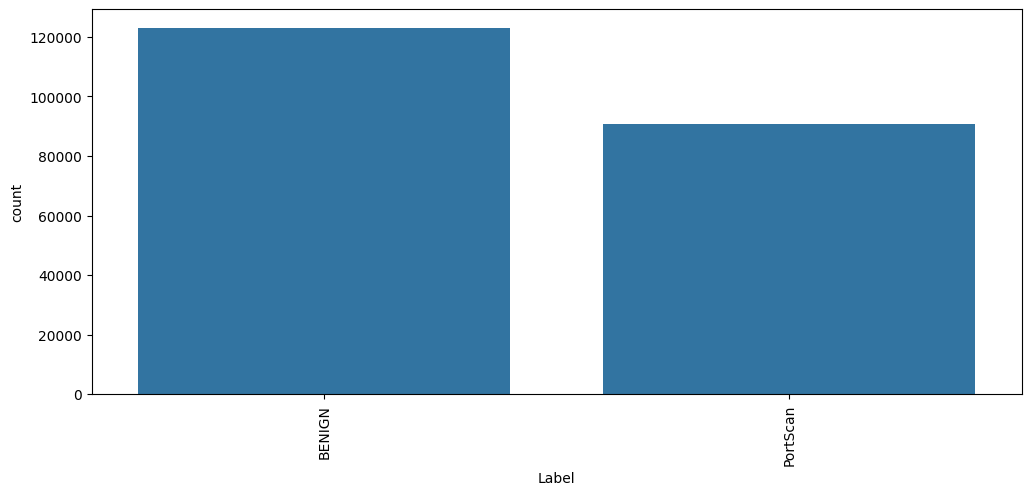

In [14]:
plt.figure(figsize=(12,5))

sns.countplot(
    x=df["Label"]
)

plt.xticks(rotation=90)
plt.show()

**Correlation Analysis**

In [15]:
corr = df.corr(numeric_only=True)

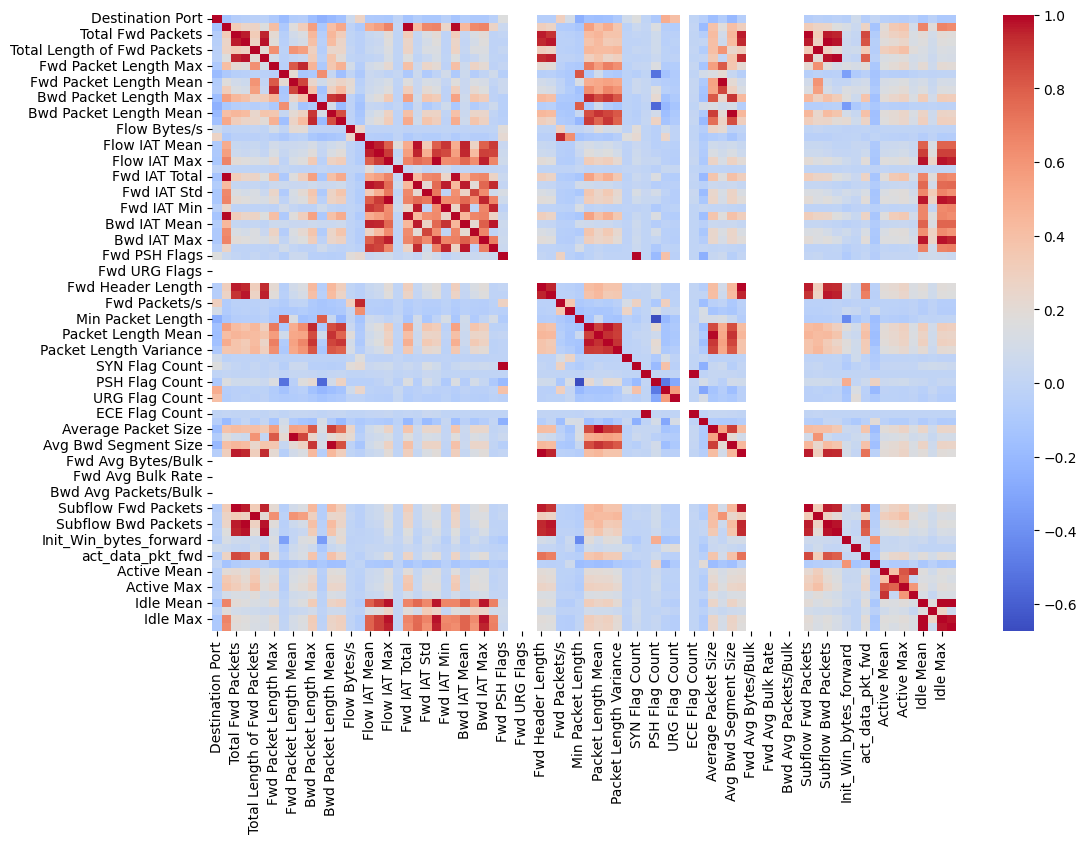

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

**Feature Distributions**

In [17]:
features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s"
]

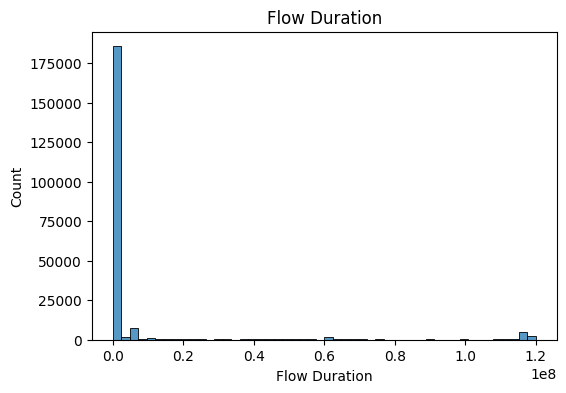

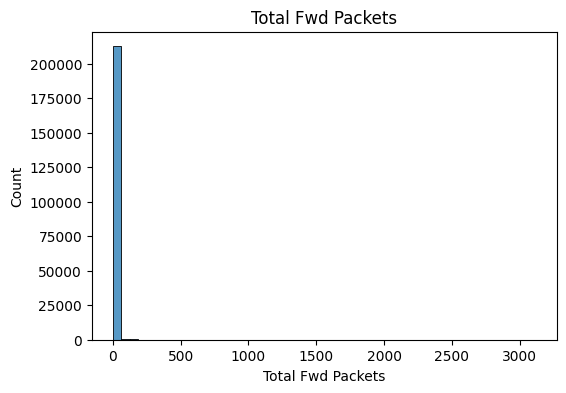

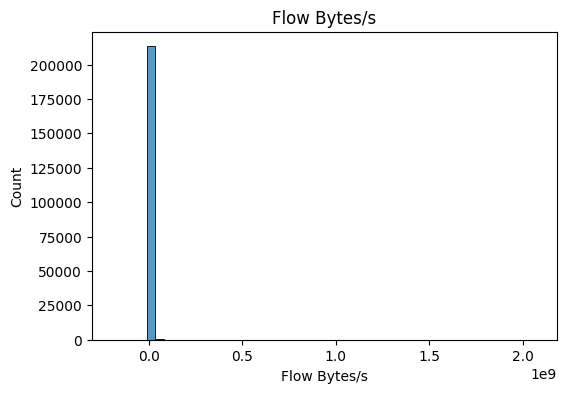

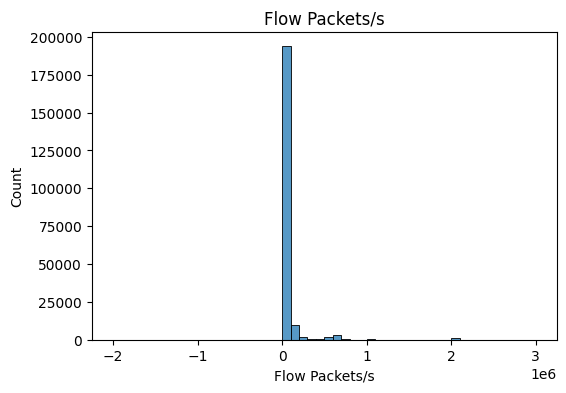

In [18]:
for col in features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        bins=50
    )

    plt.title(col)

    plt.show()

# Feature Engineering

**Separate Features**

In [19]:
X = df.drop("Label", axis=1)
y = df["Label"]

**Numeric Features Only**

In [20]:
X = X.select_dtypes(
    include=np.number
)

**Binary Labels for Evaluation**

In [21]:
y_binary = np.where(
    y == "BENIGN",
    0,
    1
)

# Feature Scaling

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA

**Explained Variance Analysis**

In [23]:
pca = PCA()

X_temp = pca.fit_transform(X_scaled)

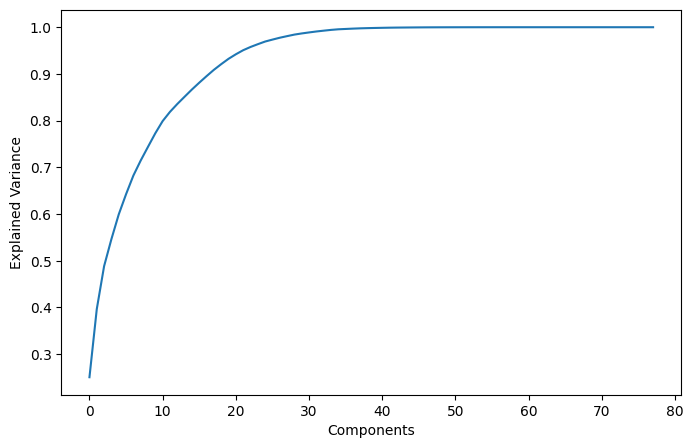

In [24]:
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    )
)

plt.xlabel("Components")
plt.ylabel("Explained Variance")

plt.show()

**Choose Components**

In [25]:
pca = PCA(
    n_components=10
)

X_pca = pca.fit_transform(
    X_scaled
)

# Model 1 — MiniBatch K-Means

**Train**

In [26]:
kmeans = MiniBatchKMeans(
    n_clusters=5,
    random_state=42,
    batch_size=5000
)

kmeans.fit(X_pca)

,n_clusters,5
,init,'k-means++'
,max_iter,100
,batch_size,5000
,verbose,0
,compute_labels,True
,random_state,42
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,'auto'


**Distance-Based Anomaly Detection**

In [27]:
distances = kmeans.transform(
    X_pca
)

In [28]:
min_distance = np.min(
    distances,
    axis=1
)

**Threshold**

In [29]:
threshold = np.percentile(
    min_distance,
    95
)

In [30]:
kmeans_pred = np.where(
    min_distance > threshold,
    1,
    0
)

**Silhouette Score**

In [31]:
silhouette_score(
    X_pca,
    kmeans.labels_
)

0.5158035855140359

# Model 2 — Isolation Forest

**Train**

In [32]:
iso_model = IsolationForest(
    contamination=0.05,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_pca)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


**Predict**

In [33]:
iso_pred = iso_model.predict(
    X_pca
)

In [34]:
iso_pred = np.where(
    iso_pred == -1,
    1,
    0
)

**Anomaly Scores**

In [35]:
iso_scores = iso_model.decision_function(
    X_pca
)

# Model 3 — One-Class SVM

**Train**

In [36]:
svm_model = OneClassSVM(
    kernel="rbf",
    gamma="auto",
    nu=0.05
)

svm_model.fit(X_pca)

,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,tol,0.001
,nu,0.05
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


**Predict**

In [37]:
svm_pred = svm_model.predict(
    X_pca
)

In [38]:
svm_pred = np.where(
    svm_pred == -1,
    1,
    0
)

# Evaluation Function

In [39]:
def evaluate_model(
    name,
    y_true,
    y_pred
):

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

# Compare Models

In [40]:
results = []

In [41]:
results.append(
    evaluate_model(
        "MiniBatch KMeans",
        y_binary,
        kmeans_pred
    )
)

In [42]:
results.append(
    evaluate_model(
        "Isolation Forest",
        y_binary,
        iso_pred
    )
)

In [43]:
results.append(
    evaluate_model(
        "One-Class SVM",
        y_binary,
        svm_pred
    )
)

In [44]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,MiniBatch KMeans,0.532031,0.062775,0.007399,0.013237
1,Isolation Forest,0.531984,0.062307,0.007343,0.013138
2,One-Class SVM,0.530810,0.051028,0.006020,0.010770


# Visual Comparison

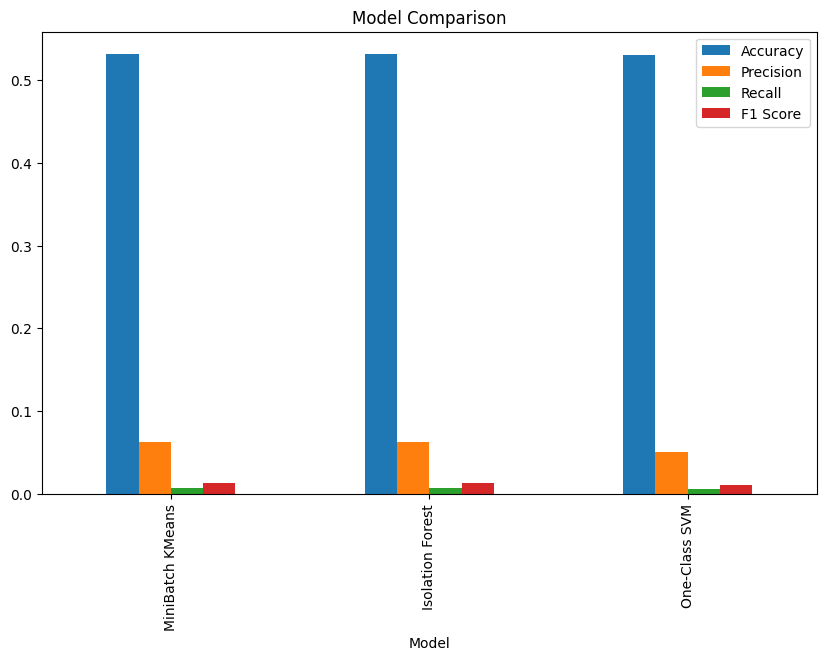

In [45]:
results_df.set_index(
    "Model"
).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Model Comparison"
)

plt.show()

# Confusion Matrices

In [46]:
models = {
    "KMeans": kmeans_pred,
    "Isolation Forest": iso_pred,
    "One-Class SVM": svm_pred
}

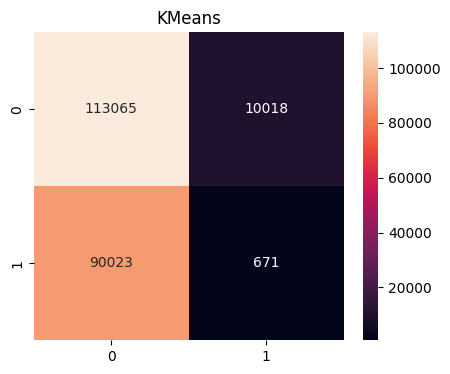

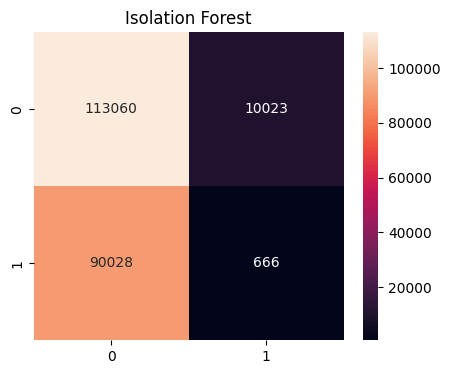

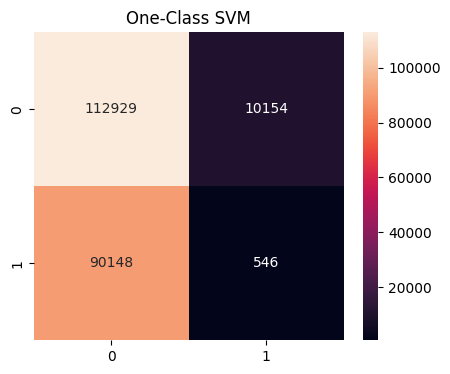

In [47]:
for name, pred in models.items():

    plt.figure(figsize=(5,4))

    sns.heatmap(
        confusion_matrix(
            y_binary,
            pred
        ),
        annot=True,
        fmt="d"
    )

    plt.title(name)

    plt.show()

# PCA Visualization

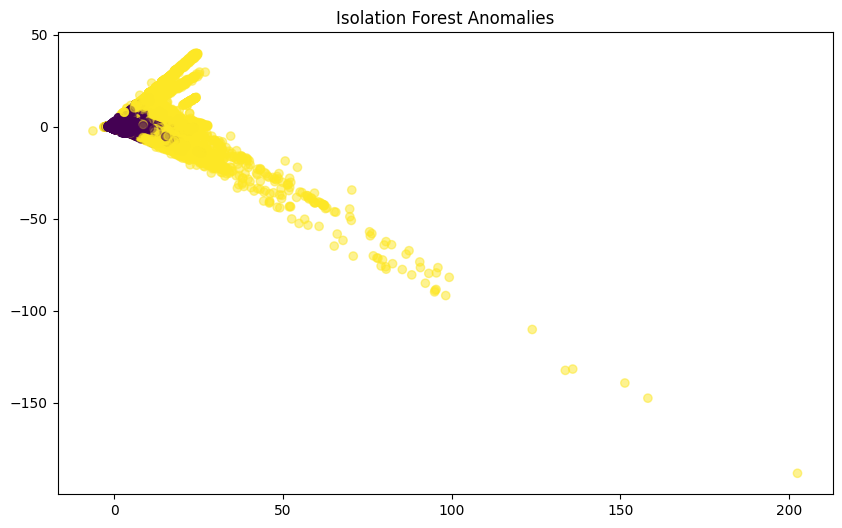

In [48]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=iso_pred,
    alpha=0.5
)

plt.title(
    "Isolation Forest Anomalies"
)

plt.show()

# Cluster Analysis

In [49]:
analysis_df = pd.DataFrame(X_pca)

analysis_df["Cluster"] = kmeans.labels_

analysis_df["Attack"] = y_binary

**Attack Rate Per Cluster**

In [50]:
cluster_attack_rate = (
    analysis_df
    .groupby("Cluster")
    ["Attack"]
    .mean()
)

In [51]:
cluster_attack_rate

Cluster
0    0.007834
1    0.000122
2    0.043953
3    0.004180
4    0.871321
Name: Attack, dtype: float64

**Cluster Size**

In [52]:
analysis_df[
    "Cluster"
].value_counts()

Cluster
4    103529
1     57525
0     28211
3     20576
2      3936
Name: count, dtype: int64

# Hybrid Detection System

In [53]:
hybrid_pred = (
    iso_pred +
    svm_pred +
    kmeans_pred
)

In [54]:
hybrid_pred = np.where(
    hybrid_pred >= 2,
    1,
    0
)

In [55]:
evaluate_model(
    "Hybrid",
    y_binary,
    hybrid_pred
)

{'Model': 'Hybrid',
 'Accuracy': 0.530983220832924,
 'Precision': 0.06148630074223403,
 'Recall': 0.007398504862504686,
 'F1 Score': 0.013207751434448413}

# Final Comparison Table

In [56]:
all_results = pd.concat([
    results_df,
    pd.DataFrame([
        evaluate_model(
            "Hybrid",
            y_binary,
            hybrid_pred
        )
    ])
])

all_results

,Model,Accuracy,Precision,Recall,F1 Score
0,MiniBatch KMeans,0.532031,0.062775,0.007399,0.013237
1,Isolation Forest,0.531984,0.062307,0.007343,0.013138
2,One-Class SVM,0.530810,0.051028,0.006020,0.010770
0,Hybrid,0.530983,0.061486,0.007399,0.013208


# Clustering Visualizations

**PCA Cluster Visualization**

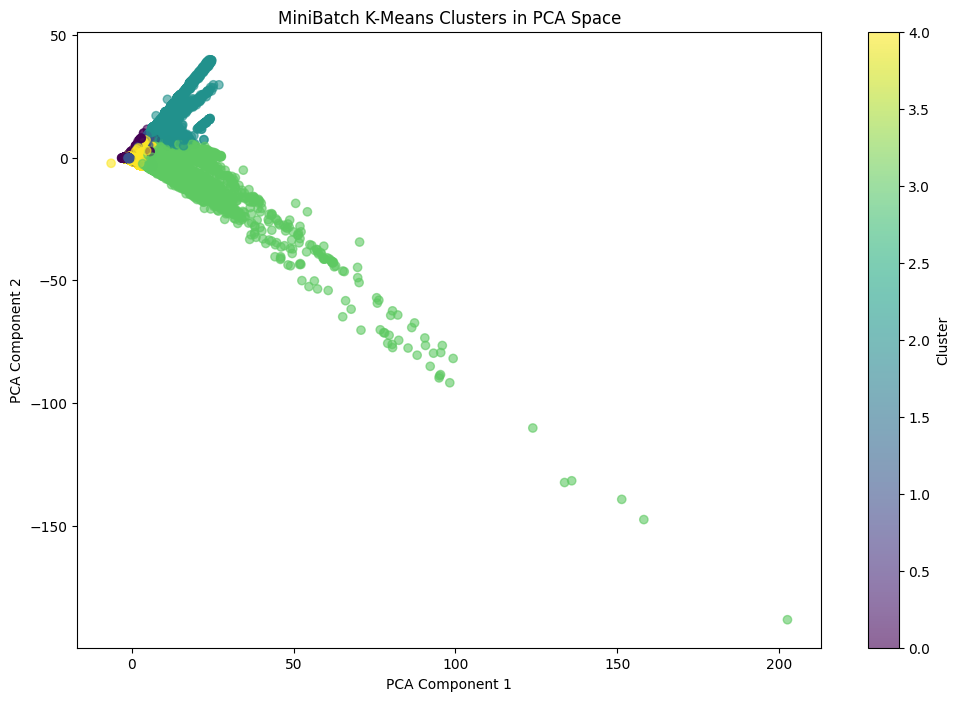

In [57]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans.labels_,
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("MiniBatch K-Means Clusters in PCA Space")

plt.colorbar(scatter, label="Cluster")

plt.show()

**Cluster Centers Visualization**

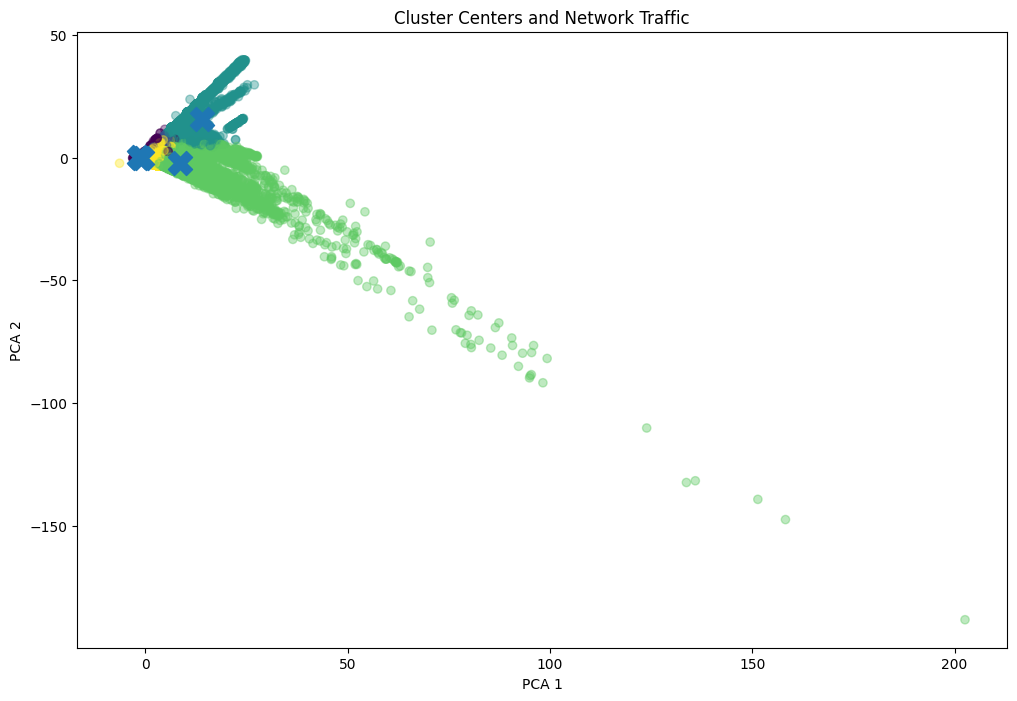

In [58]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(12,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans.labels_,
    alpha=0.4
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=300,
    marker='X'
)

plt.title("Cluster Centers and Network Traffic")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

**Highlight Detected Anomalies**

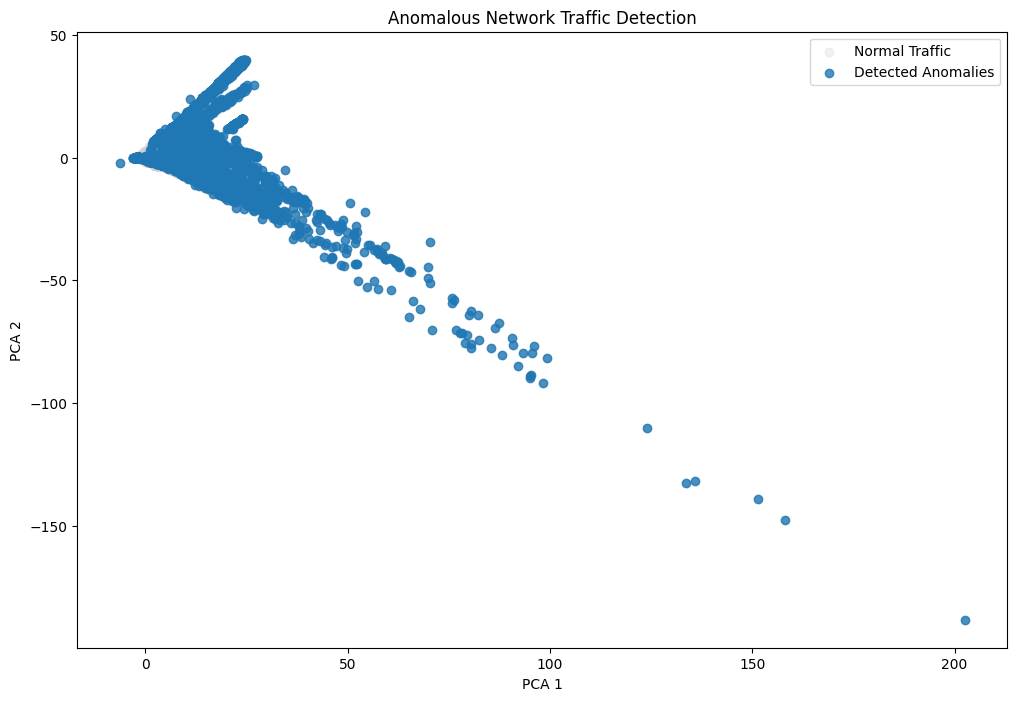

In [59]:
plt.figure(figsize=(12,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c="lightgray",
    alpha=0.3,
    label="Normal Traffic"
)

anomaly_idx = np.where(kmeans_pred == 1)

plt.scatter(
    X_pca[anomaly_idx,0],
    X_pca[anomaly_idx,1],
    alpha=0.8,
    label="Detected Anomalies"
)

plt.title("Anomalous Network Traffic Detection")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.legend()

plt.show()

**True Attack vs Benign Visualization**

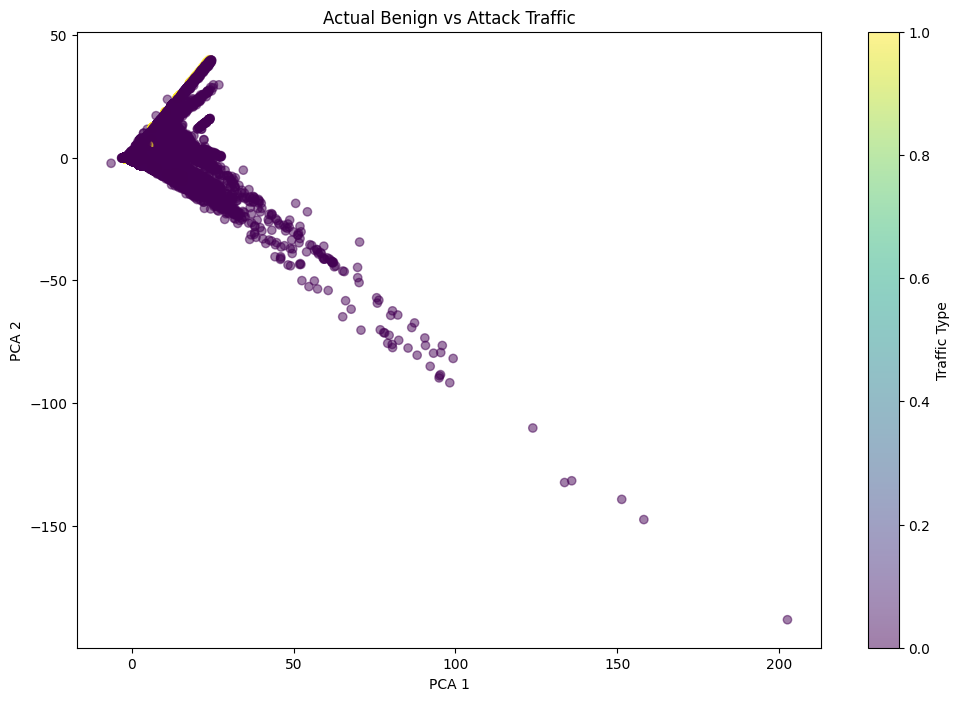

In [60]:
plt.figure(figsize=(12,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_binary,
    alpha=0.5
)

plt.title("Actual Benign vs Attack Traffic")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.colorbar(label="Traffic Type")

plt.show()

**Attack Percentage per Cluster**

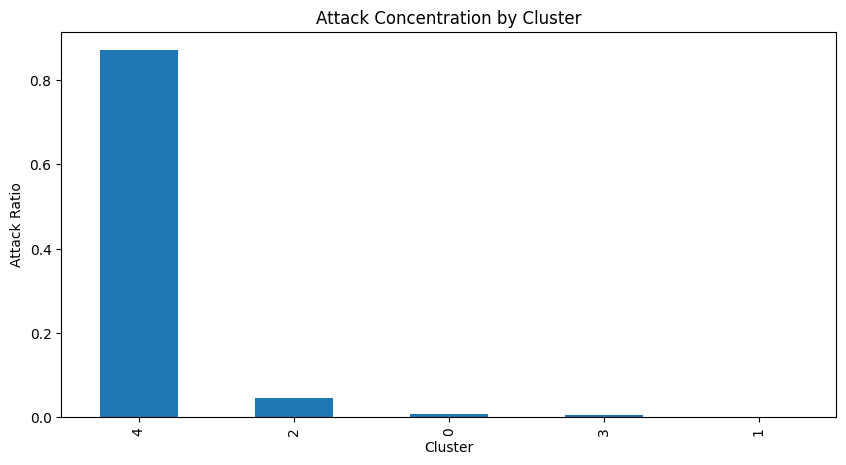

In [61]:
cluster_analysis = pd.DataFrame({
    "Cluster": kmeans.labels_,
    "Attack": y_binary
})

attack_rate = (
    cluster_analysis
    .groupby("Cluster")["Attack"]
    .mean()
    .sort_values(ascending=False)
)

attack_rate.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Attack Ratio")
plt.title("Attack Concentration by Cluster")

plt.show()

**Cluster Size Distribution**

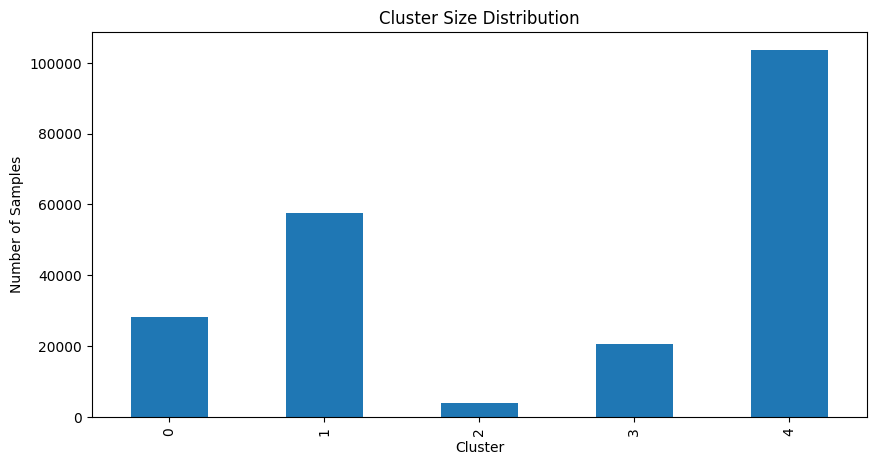

In [62]:
pd.Series(kmeans.labels_).value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")

plt.show()

**PCA 3D Visualization**

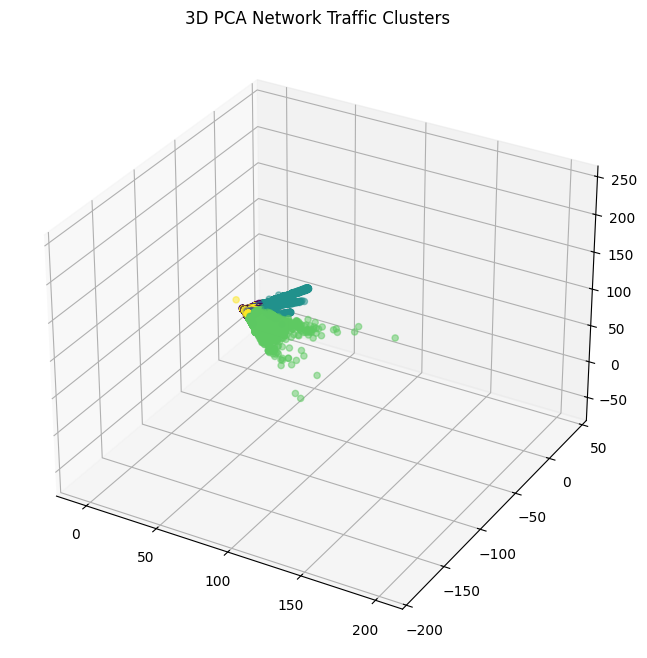

In [63]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=kmeans.labels_,
    alpha=0.5
)

ax.set_title("3D PCA Network Traffic Clusters")

plt.show()

In [64]:
import joblib

# Preprocessing
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

# Models
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(iso_model, "isolation_forest.pkl")
joblib.dump(svm_model, "oneclass_svm.pkl")

print("All models saved successfully!")

All models saved successfully!
